## 6. Analisis Exploratorio de Datos

6.1 Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Interpretación

Las librerías importadas permiten realizar procesos de manipulación, análisis y visualización de datos. Pandas y NumPy se utilizan para el manejo de estructuras de datos, mientras que Matplotlib y Seaborn facilitan la construcción de gráficos para el análisis exploratorio.

6.2 Cargue Inicial de los Datos

In [2]:
df = pd.read_csv("water_potability_clean.csv")

In [3]:
df.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Interpretación

Se carga el conjunto de datos de potabilidad del agua en un DataFrame de Pandas. Posteriormente, se visualizan las primeras filas con el fin de verificar que la información haya sido importada correctamente y conocer la estructura inicial de los datos.

6.3 Información General del Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


Interpretación

Permite identificar:

1 Número de registros.

2 Tipo de dato de cada variable.

3 Cantidad de valores no nulos.

4 Presencia inicial de datos faltantes.

6.4 Estadísticas descriptivas

In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Interpretación

Las estadísticas descriptivas permiten conocer el comportamiento general de las variables numéricas. Se observa que las características presentan diferentes rangos y niveles de dispersión, evidenciando variabilidad en las mediciones de calidad del agua.

6.5 Analizar y Visualizar la Variable Objetivo

In [6]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

C:\Users\mmay\AppData\Local\Temp\ipykernel_26092\361392415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\mmay\AppData\Local\Temp\ipykernel_26092\361392415.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Potable', 'Potable'])


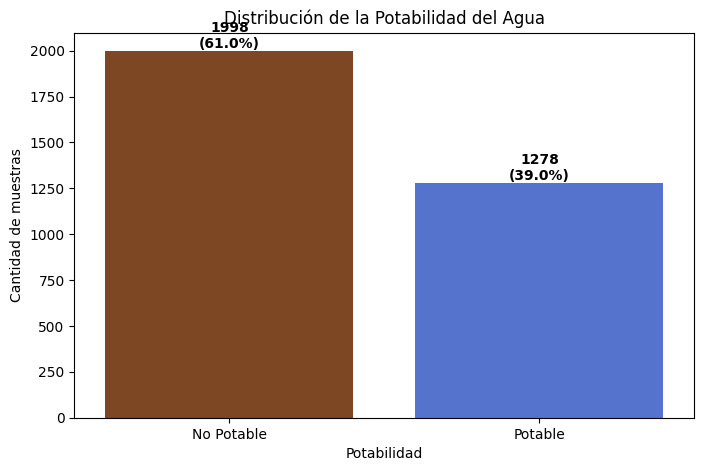

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteos
conteos = df['Potability'].value_counts().sort_index()
total = len(df)

# Gráfico
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=df,
    x='Potability',
    palette=['saddlebrown', 'royalblue']
)

# Cambiar etiquetas
ax.set_xticklabels(['No Potable', 'Potable'])

# Agregar cantidad y porcentaje sobre cada barra
for p in ax.patches:
    cantidad = int(p.get_height())
    porcentaje = 100 * cantidad / total

    ax.annotate(
        f'{cantidad}\n({porcentaje:.1f}%)',
        (p.get_x() + p.get_width()/2., cantidad),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Distribución de la Potabilidad del Agua')
plt.xlabel('Potabilidad')
plt.ylabel('Cantidad de muestras')
plt.show()

Interpretación

La variable Potability presenta dos categorías: agua no potable y agua potable. Se observa que la categoría No potable concentra la mayor cantidad de registros, con aproximadamente el 61% de las muestras, mientras que la categoría Potable representa cerca del 39%. Esto evidencia un desbalance moderado entre las clases, aspecto que deberá considerarse en las etapas posteriores de modelado.

6.6. Identificación y Visualización de las variables que se relacionan más con la potabilidad

In [8]:
corr_potability = df.corr(numeric_only=True)['Potability'].sort_values(ascending=False)

corr_potability

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

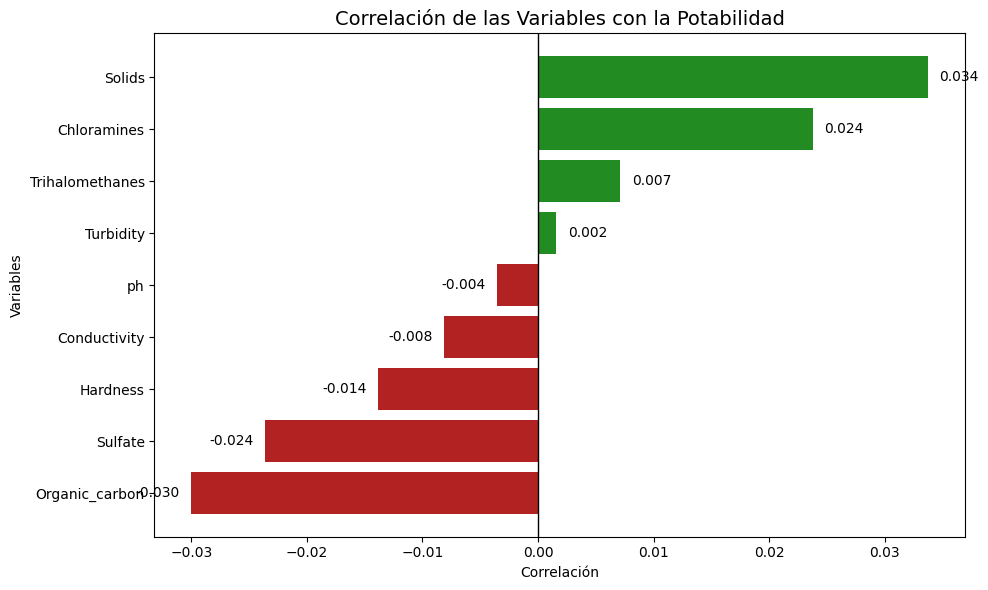

In [9]:
import matplotlib.pyplot as plt
import numpy as np

corr_plot = (
    corr_potability
    .drop('Potability')
    .sort_values()
)

# Colores según el signo de la correlación
colors = ['firebrick' if x < 0 else 'forestgreen' for x in corr_plot]

plt.figure(figsize=(10,6))

bars = plt.barh(
    corr_plot.index,
    corr_plot.values,
    color=colors
)

# Etiquetas de los valores
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001 if width >= 0 else width - 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center',
        ha='left' if width >= 0 else 'right'
    )

plt.axvline(x=0, color='black', linewidth=1)

plt.title('Correlación de las Variables con la Potabilidad', fontsize=14)
plt.xlabel('Correlación')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

Interpretación

Ninguna de las variables presenta una correlación lineal fuerte con la potabilidad del agua. Las correlaciones obtenidas son muy bajas y cercanas a cero, lo que indica que la potabilidad no depende de una única característica fisicoquímica. La variable con mayor correlación positiva es Solids (0.0337), mientras que Organic_carbon (-0.0300) presenta la mayor correlación negativa; sin embargo, ambas relaciones son débiles.

6.7 Matriz de correlación

Ahora vamos a analizar la relación entre todas las variables.

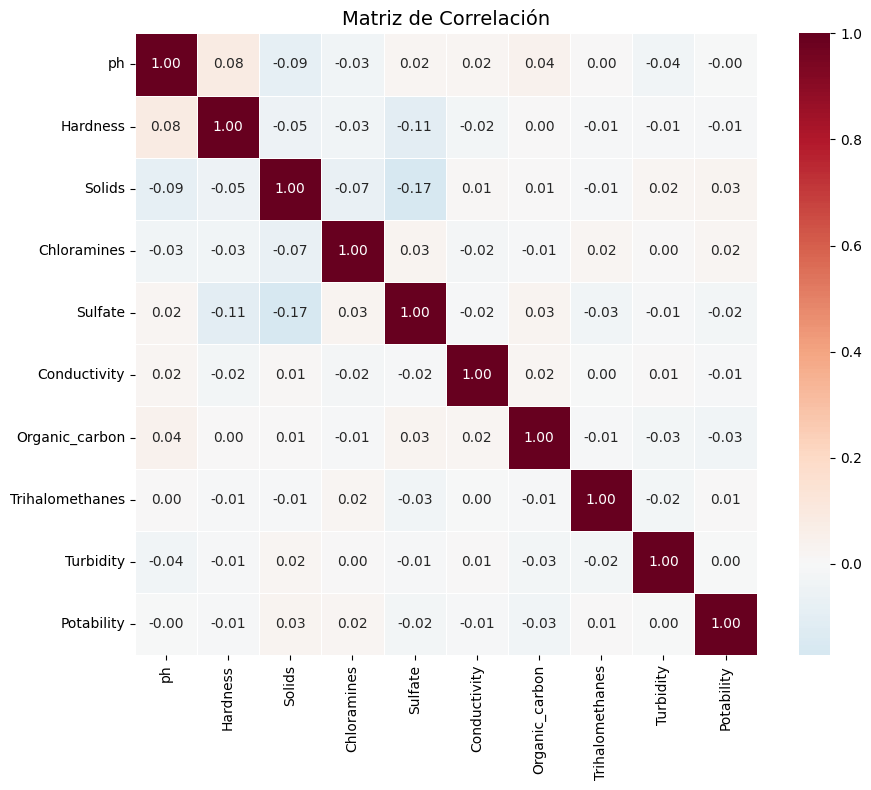

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de correlación
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()

plt.show()